In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

pswm = pd.read_csv("pswm_final.csv", index_col=0)
pswm.columns = pswm.columns.astype(int)

print(pswm.shape)
print(pswm.index)
print(pswm.columns)

(20, 15)
Index(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q',
       'R', 'S', 'T', 'V', 'W', 'Y'],
      dtype='object')
Index([-13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1], dtype='int64')


In [48]:
def read_fasta_to_dict():
    seqs = {}
    with open("benchmark.fasta", "r") as f:
        current_id = None
        current_seq = []
        for line in f:
            line = line.strip()
            if line.startswith(">"):
                if current_id is not None:
                    seqs[current_id] = "".join(current_seq)
                current_id = line[1:].split()[0]
                current_seq = []
            else:
                current_seq.append(line)
        if current_id is not None: 
            seqs[current_id] = "".join(current_seq) 
    return seqs
bench= read_fasta_to_dict()

best_pos = {}   # seq_id → index of -13 position

def score_bench(bench, pswm):

    pswm_arr = pswm.to_numpy()
    aa_to_idx = {aa: i for i, aa in enumerate(pswm.index)}
    pos_to_idx = {pos: i for i, pos in enumerate(pswm.columns)}

    window_size = 15
    index = list(range(-13, 2))
    results = {}

    for seq_id, seq in bench.items():
        seq_scores = []
        valid_starts = []

        max_start = min(len(seq), 90) - window_size + 1

        for i in range(max_start):
            window = seq[i:i + window_size]
            try:
                score = sum(
                    pswm_arr[aa_to_idx[aa], pos_to_idx[pos]]
                    for aa, pos in zip(window, index)
                )
            except KeyError:
                continue  # skip invalid windows

            seq_scores.append(score)
            valid_starts.append(i)

        if len(seq_scores) == 0:
            results[seq_id] = np.nan
            best_pos[seq_id] = None
            continue

        best_idx = np.argmax(seq_scores)
        best_start = valid_starts[best_idx]

        results[seq_id] = seq_scores[best_idx]
        best_pos[seq_id] = best_start  # THIS is the true -13 position

    return results
scores  = score_bench(bench, pswm)

[('P04275', 15.433734547876753), ('P04844', 13.983033765040739), ('P07359', 17.088493697076824), ('P13671', 7.792694152901856), ('P19438', 7.124579471773328)]


In [49]:
# testing the threshold on benchmarking data
info= pd.read_csv("all.tsv", sep="\t")
label_mapping = dict(zip(info["UniprotAccession"], info["label"]))
bench_labels={}
for seq_id in scores.keys():
    if seq_id in label_mapping:
        if label_mapping[seq_id] == "positive":
            bench_labels[seq_id] = 1
        else:
            bench_labels[seq_id] = 0   

In [63]:
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    matthews_corrcoef, confusion_matrix
)
threshold= 6.141
# Build y_true and y_pred lists
y_true = []
y_pred = []

for seq_id, score in scores.items():
    true_label = bench_labels[seq_id]      # 1 for positive, 0 for negative
    predicted_label = 1 if score >= threshold else 0

    y_true.append(true_label)
    y_pred.append(predicted_label)

# Compute metrics
f1 = f1_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
mcc = matthews_corrcoef(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)

print("Confusion matrix:\n", cm)

print(f"F1={f1:.3f}, Precision={precision:.3f}, Recall={recall:.3f}, MCC={mcc:.3f}")

Confusion matrix:
 [[1548  239]
 [   8  211]]
F1=0.631, Precision=0.469, Recall=0.963, MCC=0.620


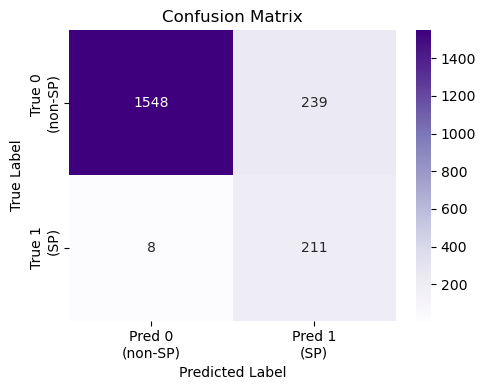

In [62]:
# Plot the matrix
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Pred 0\n(non-SP)', 'Pred 1\n(SP)'],
            yticklabels=['True 0\n(non-SP)', 'True 1\n(SP)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig("CM_VH_performance.png")
plt.show()


In [66]:
# Add predictions and ground truth
info["true_label"] = info["label"].map({"positive": 1, "negative": 0})
info["score"] = info["UniprotAccession"].map(scores)
info["predicted"] = (info["score"] >= threshold).astype(int)
# Compute TP, TN, FP, FN counts per kingdom
summary = (
    info.groupby("Kingdom")
    .apply(lambda x: pd.Series({
        "TP": ((x["true_label"] == 1) & (x["predicted"] == 1)).sum(),
        "TN": ((x["true_label"] == 0) & (x["predicted"] == 0)).sum(),
        "FP": ((x["true_label"] == 0) & (x["predicted"] == 1)).sum(),
        "FN": ((x["true_label"] == 1) & (x["predicted"] == 0)).sum()
    }))
    .reset_index()
)
summary
summary_percent = summary.copy()
summary_percent[["TP","TN","FP","FN"]] = (
    summary[["TP","TN","FP","FN"]]
    .div(summary[["TP","TN","FP","FN"]].sum(axis=1), axis=0) * 100
)
display(summary)
display(round(summary_percent, 2))

,Kingdom,TP,TN,FP,FN
0,Fungi,15,2450,25,80
1,Metazoa,167,4545,152,699
2,Other,3,163,5,25
3,Viridiplantae,26,1537,57,77


,Kingdom,TP,TN,FP,FN
0,Fungi,0.58,95.33,0.97,3.11
1,Metazoa,3.00,81.70,2.73,12.57
2,Other,1.53,83.16,2.55,12.76
3,Viridiplantae,1.53,90.57,3.36,4.54


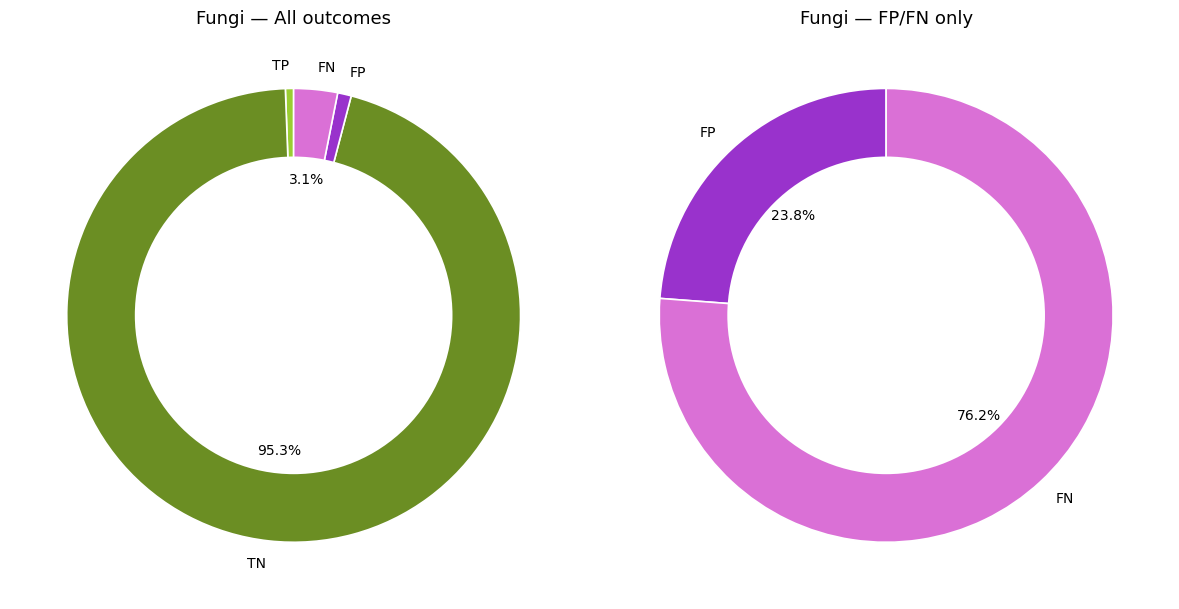

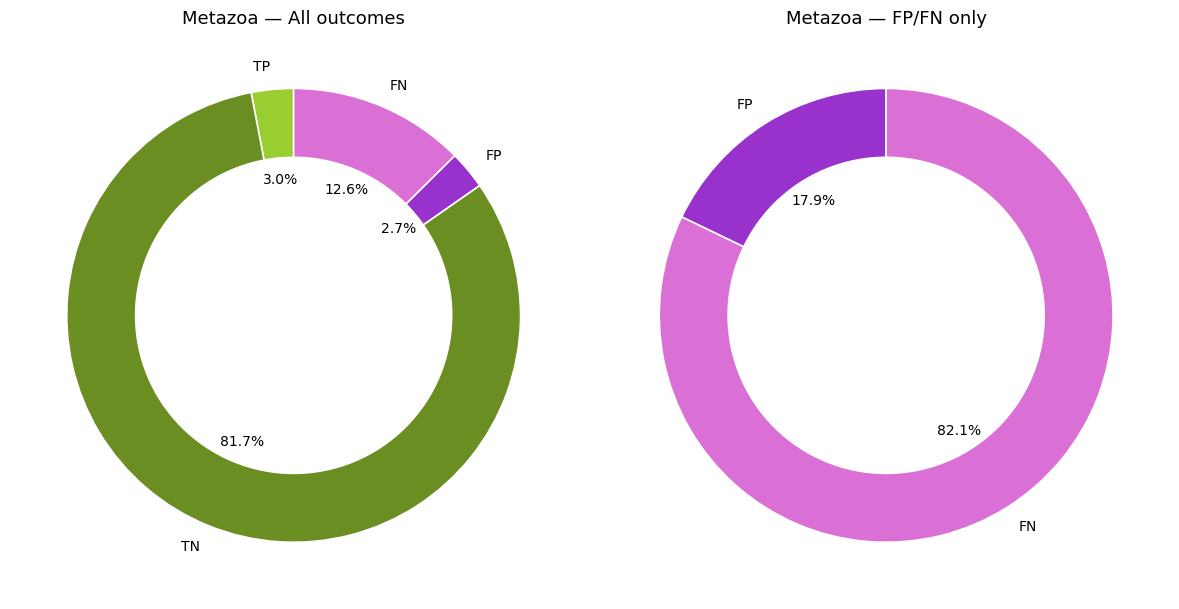

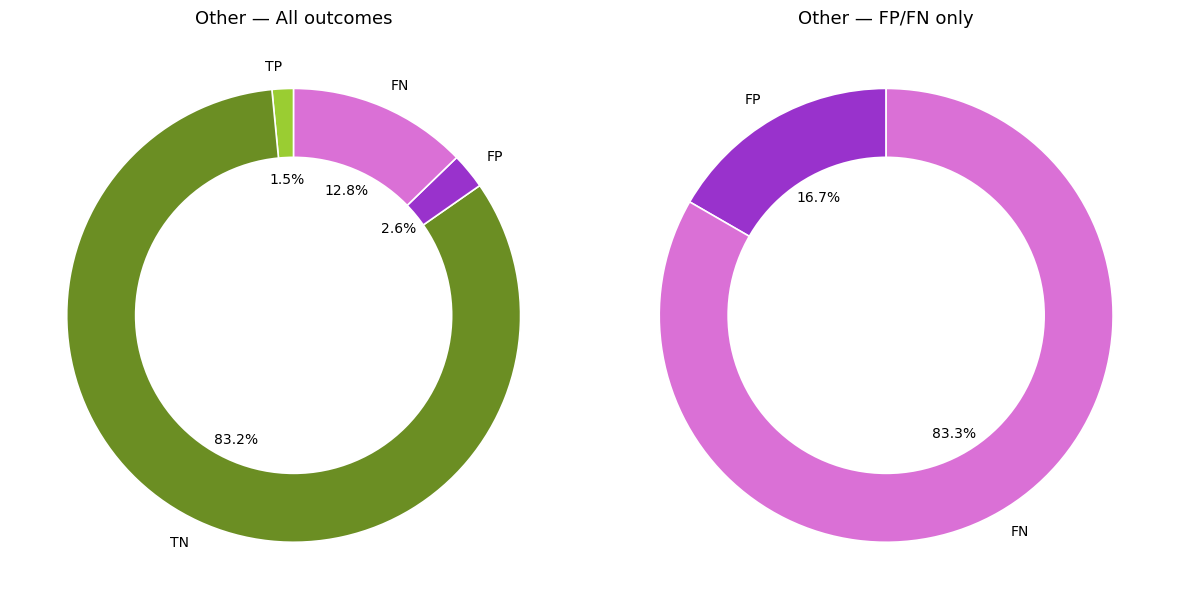

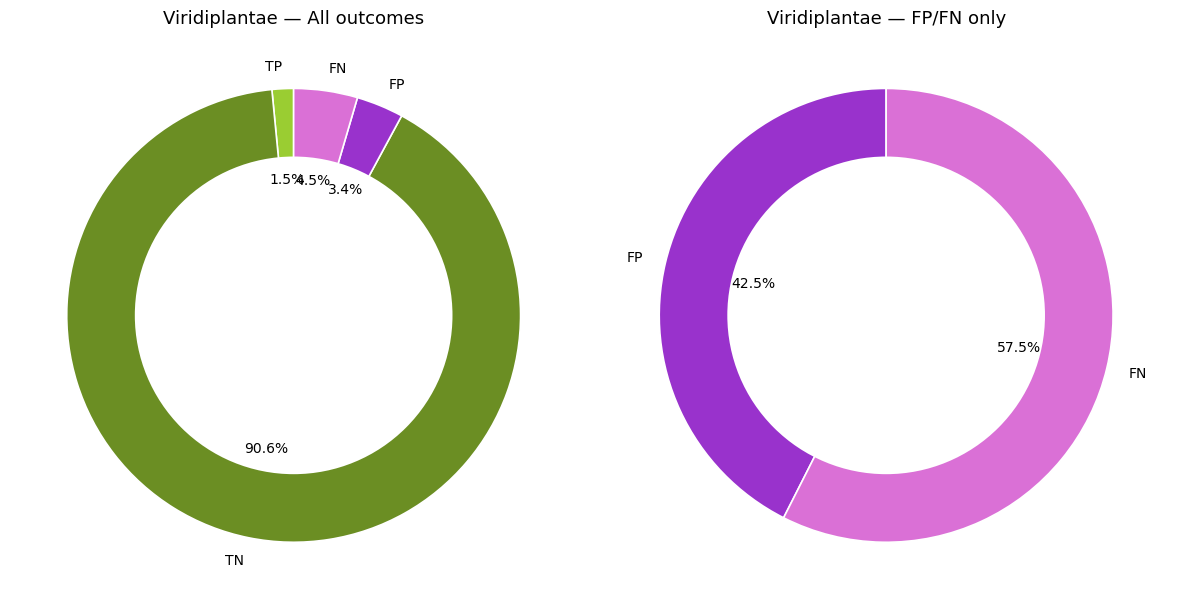

In [19]:
import matplotlib.pyplot as plt

# Define full and error-only columns + colors
cols_all = ["TP", "TN", "FP", "FN"]
cols_errors = ["FP", "FN"]

colors_all = ["yellowgreen", "olivedrab", "darkorchid", "orchid"]  
colors_errors = ["darkorchid", "orchid"] 

for kingdom in summary_percent["Kingdom"]:
    row = summary_percent[summary_percent["Kingdom"] == kingdom].iloc[0]

    # Extract values for both sets
    values_all = row[cols_all]
    values_errors = row[cols_errors]

    # Create side-by-side donuts
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'width_ratios': [6, 6]})

    # Donut 1: All outcomes
    wedges, texts, autotexts = ax[0].pie(
        values_all,
        labels=cols_all,
        autopct=lambda p: f"{p:.1f}%" if p > 1 else "",
        startangle=90,
        colors=colors_all,
        textprops={'fontsize': 10, 'color': 'black'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
    )
    ax[0].add_artist(plt.Circle((0, 0), 0.70, fc='white'))
    ax[0].set_title(f"{kingdom} — All outcomes", fontsize=13)

    # Donut 2: Only FP and FN 
    wedges, texts, autotexts = ax[1].pie(
        values_errors,
        labels=cols_errors,
        autopct=lambda p: f"{p:.1f}%" if p > 0 else "",
        startangle=90,
        colors=colors_errors,
        textprops={'fontsize': 10, 'color': 'black'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.2}
    )
    ax[1].add_artist(plt.Circle((0, 0), 0.70, fc='white'))
    ax[1].set_title(f"{kingdom} — FP/FN only", fontsize=13)

    plt.tight_layout()
    plt.savefig(f"donut{kingdom}.png")

    plt.show()
    

In [61]:
# # FALSE NEGATIVE ANALYSIS
# storing FNs
FN_ids = [
    seq_id for seq_id, score in scores.items() if bench_labels[seq_id] == 1 and score < threshold]

FN_windows = {}
window_size = 15

for seq_id in FN_ids:

    seq = bench[seq_id]

    # Get SPPosition (1-based)
    sp_pos = int(info.loc[info["UniprotAccession"] == seq_id, "SPPosition"].values[0])

    # Convert to Python (0-based)
    cleavage_pos = sp_pos - 1

    # Window [-13 .. +1] relative to cleavage site
    start = cleavage_pos - 13
    end   = cleavage_pos + 2      

    # Extract subsequence
    window = seq[start:end]

    # Pad on left if window extends before seq start

    FN_windows[seq_id] = window

# Save FASTA
with open("FN_logo3.fasta", "w") as f:
    for sid, win in FN_windows.items():
        f.write(f">{sid}\n{win}\n")
# creating logo
# logo is “flat” because the FNs are HETEROGENEOUS